In [1]:
import pandas as pd
import rdkit
import deepchem
print("Enfin prêt sur Mac !")

Skipped loading some Pytorch utilities, missing a dependency. No module named 'torch'
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading some PyTorch models, missing a dependency. No module named 'torch'
No module named 'torch'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'torch'
Skipped loading some Jax

This module requires PyTorch to be installed.
Enfin prêt sur Mac !


In [2]:
import pandas as pd

# Comme le fichier est dans le même dossier que ton notebook,
# il suffit d'écrire son nom exact.
df = pd.read_csv('df_elec.csv')

print(f"✅ Succès ! {len(df)} molécules chargées.")
display(df.head())

✅ Succès ! 534119 molécules chargées.


,Unnamed: 0,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set
0,0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5
1,1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2
2,2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3
3,3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1
4,4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3


In [3]:
import numpy as np

# Chemin vers le fichier des electrophiles

path_elec = 'df_elec.csv'

# Pandas gère la décompression (.gz) automatiquement
df_elec = pd.read_csv(path_elec)

# Nettoyage du database pour n'avoir qu'un site électrophile par molécule (le meilleur)
df_meilleur = df_elec.sort_values('MAA_values', ascending=False).drop_duplicates('smiles')
df_propre1 = df_meilleur.drop(columns=['elec_GCS_3_cm5'])
df_propre2 = df_propre1.drop(columns=['elec_sites'])

print(f"Dataset chargé : {len(df_propre2)} électrophiles trouvés.")

# Refaire 4 training set et 1 validation

def create_custom_sets(df):
    """Crée 5 groupes de 20% (4 Train, 1 Test) basés sur les SMILES"""
    smiles_list = df['smiles'].values

    # Mélange reproductible
    np.random.seed(42)
    np.random.shuffle(smiles_list)

    n = len(smiles_list)
    s = n // 5

    # Création du mapping
    mapping = {}
    for i in range(4):
        fold_smiles = smiles_list[i*s : (i+1)*s]
        for s_val in fold_smiles:
            mapping[s_val] = f'Train_fold{i+1}'

    # Le reste dans le Test
    test_smiles = smiles_list[4*s:]
    for s_val in test_smiles:
        mapping[s_val] = 'Test'

    df['new_set'] = df['smiles'].map(mapping)
    return df

# 2. Création de la colonne de set
df_propre3 = create_custom_sets(df_propre2)

df_propre4 = df_propre3.drop(columns=['Set'])
df_propre5 = df_propre4.drop(columns=['elec_names'])
df_final = df_propre5.drop(columns=['Unnamed: 0'])
display(df_final.head())
print(df_final.columns.tolist())

# Compte le nombre de molécules pour chaque catégorie du set
print(df_final['new_set'].value_counts())




Dataset chargé : 47440 électrophiles trouvés.


,smiles,MAA_values,new_set
21117,COc1cccc(CNCCc2c[nH]c3ccccc23)c1OCc1ccccc1,446.103949,Train_fold1
122396,Cc1cc2cc(C(=O)N(C)C)c(=O)oc2c2ccccc12,407.555071,Train_fold1
46102,Cc1ccc(C)c(C(=O)NCc2ccncc2)c1,401.051562,Train_fold1
524595,COc1cccc(Nc2cc(=O)oc3c2ccc2ccccc23)c1,396.173779,Train_fold1
55462,Cc1ccc(-c2ccsc2S(=O)(=O)Nc2onc(C)c2Br)cc1,391.829610,Train_fold1


['smiles', 'MAA_values', 'new_set']
new_set
Train_fold1    9488
Train_fold2    9488
Train_fold3    9488
Train_fold4    9488
Test           9488
Name: count, dtype: int64


In [22]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np
from tqdm.auto import tqdm

def smiles_to_fp(smiles, radius=2, nBits=2048):
    if not isinstance(smiles, str):
        return np.zeros(nBits, dtype=np.int8)
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        arr = np.zeros((1,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return np.zeros(nBits, dtype=np.int8)

# 1. On garde le nom 'features' comme avant
print("Génération des Morgan Fingerprints...")
features = np.array([smiles_to_fp(s) for s in tqdm(df_final['smiles'], desc="Calcul des Fingerprints")])

# 2. On garde tes noms de split habituels
X_train = features[is_train]
y_train = df_final.loc[is_train, 'MAA_values'].values

X_test = features[is_test]
y_test = df_final.loc[is_test, 'MAA_values'].values

print(f"\nTerminé ! Matrice 'features' générée : {features.shape}")
print(f"Entraînement : {X_train.shape[0]} molécules")
print(f"Test : {X_test.shape[0]} molécules")

Génération des Morgan Fingerprints...


[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerator
[17:13:28] DEPRECATION WARNING: please use MorganGenerat


Terminé ! Matrice 'features' générée : (47440, 2048)
Entraînement : 37952 molécules
Test : 9488 molécules


In [23]:
# On sauvegarde la matrice sur ton Mac pour ne plus jamais avoir à refaire le calcul
np.save('features_electrophiles.npy', features)
print("Fichier sauvegardé sur le disque !")

Fichier sauvegardé sur le disque !


In [54]:
# 1. Suppression des colonnes vides (indispensable pour gagner du temps)
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
features = selector.fit_transform(features) 
print(f"Descripteurs après filtrage : {features.shape[1]}")

from sklearn.model_selection import train_test_split
# 2. Le Split (INDISPENSABLE)
# On utilise features (tes Morgan Fingerprints)
# On écrase les anciens noms avec le nouveau split mélangé
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    df_final['MAA_values'], 
    test_size=0.2, 
    random_state=42
)

print(f"✅ Nouveau split terminé avec les mêmes noms.")
print(f"Moyenne Train : {y_train.mean():.2f}")
print(f"Moyenne Test : {y_test.mean():.2f}")
print(f"Taille du X_test : {X_test.shape}")

print("Prêt pour l'entraînement !")

Descripteurs après filtrage : 2048
✅ Nouveau split terminé avec les mêmes noms.
Moyenne Train : 179.82
Moyenne Test : 179.46
Taille du X_test : (9488, 2048)
Prêt pour l'entraînement !


In [55]:
import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, n_jobs=4, verbose=1)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    n_jobs=4,        # <--- Booster sans crash
    random_state=42
)

In [56]:
import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error

# On crée une liste pour stocker tous les scores
all_results = []
# Un dictionnaire pour stocker les prédictions (utile pour les graphiques plus tard)
all_preds = {}

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores à notre liste globale
    all_results.append({
        "Modèle": name,
        "RMSE Train": round(train_rmse, 4),
        "RMSE Test": round(test_rmse, 4),
        "Diff (Overfit)": round(abs(train_rmse - test_rmse), 4)
    })

    # On retourne les prédictions du test set
    return y_pred_test

# --- LANCEMENT ---

all_results = []



In [58]:
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")


✨ Random Forest Terminé: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]


✨ XGBoost Terminé: 100%|██████████| 3/3 [00:01<00:00,  2.03it/s]


📊 RÉCAPITULATIF DES PERFORMANCES :


,Modèle,RMSE Train,RMSE Test,Diff (Overfit)
0,Random Forest,56.4850,56.8583,0.3733
1,XGBoost,54.2959,57.0951,2.7992


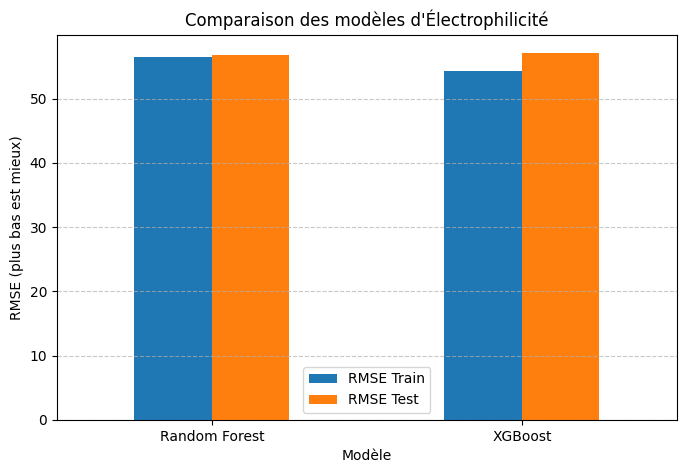

In [59]:
# On récupère les prédictions dans des variables dédiées
preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

# --- AFFICHAGE FINAL ---

df_results = pd.DataFrame(all_results)
print("\n📊 RÉCAPITULATIF DES PERFORMANCES :")
display(df_results)

# Graphique de comparaison
df_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', figsize=(8, 5))
plt.ylabel("RMSE (plus bas est mieux)")
plt.title("Comparaison des modèles d'Électrophilicité")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

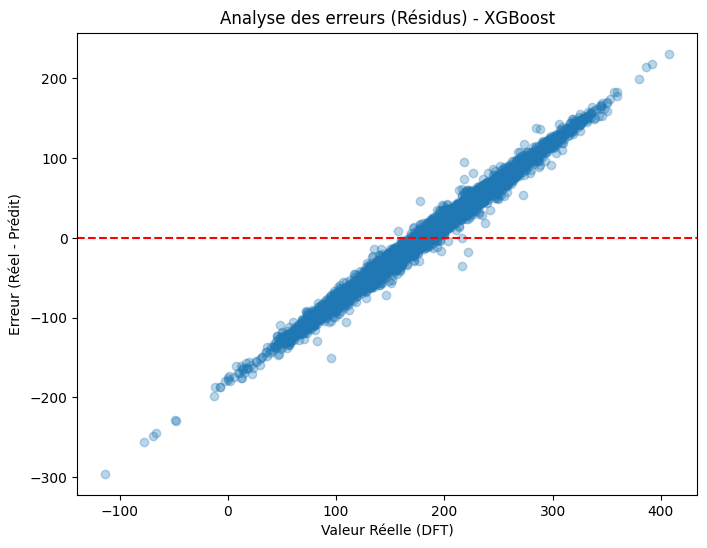

In [61]:
# Exemple pour analyser le XGBoost
plt.figure(figsize=(8, 6))
plt.scatter(y_test, (y_test - preds_xgb), alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Analyse des erreurs (Résidus) - XGBoost")
plt.xlabel("Valeur Réelle (DFT)")
plt.ylabel("Erreur (Réel - Prédit)")
plt.show()

In [11]:
import joblib

# Sauvegarde du Random Forest
joblib.dump(ranf_reg, 'rf_model_chemistry.joblib')

# Sauvegarde du XGBoost
joblib.dump(xgb_reg, 'xgb_model_chemistry.joblib')

print("✅ Modèles sauvegardés ! Tu peux fermer VS Code sereinement.")

✅ Modèles sauvegardés ! Tu peux fermer VS Code sereinement.


✨ XGBoost Terminé: 100%|██████████| 3/3 [00:02<00:00,  1.42it/s]


⏳ Début de l'analyse SVM (cela peut être long sur 50k lignes)...


✨ SVM Terminé: 100%|██████████| 3/3 [03:31<00:00, 70.47s/it] 


📊 RÉCAPITULATIF FINAL :


,Modèle,RMSE Train,RMSE Test,Diff (Overfit)
0,Random Forest,42.0211,102.3584,60.3372
1,XGBoost,38.2948,102.6001,64.3053
2,SVM,43.7177,96.4847,52.7670


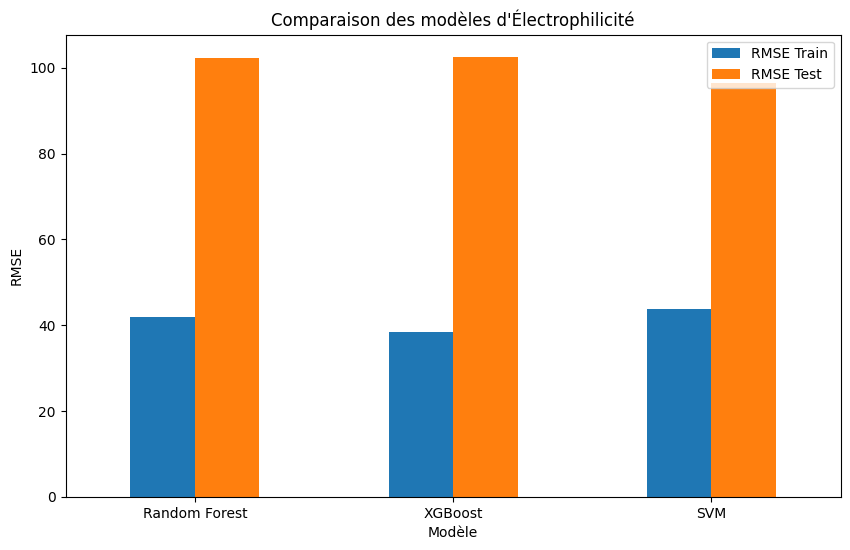

In [12]:
# 1. Création du modèle SVM
from sklearn.svm import SVR
svm_reg = SVR(kernel='rbf', C=1, epsilon=0.1) # Paramètres standards

# 2. Lancement (On récupère aussi les prédictions)
# On réinitialise la liste pour ne pas accumuler les vieux runs si on veut un tableau frais
all_results = []

preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")
preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

print("⏳ Début de l'analyse SVM (cela peut être long sur 50k lignes)...")
preds_svm = train_test_model(svm_reg, X_train, y_train, X_test, y_test, name="SVM")

# 3. AFFICHAGE DES RÉSULTATS (Le tableau comparatif)
df_results = pd.DataFrame(all_results)
print("\n📊 RÉCAPITULATIF FINAL :")
display(df_results)

# 4. Graphique de comparaison
df_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', figsize=(10, 6))
plt.ylabel("RMSE")
plt.title("Comparaison des modèles d'Électrophilicité")
plt.xticks(rotation=0)
plt.show()

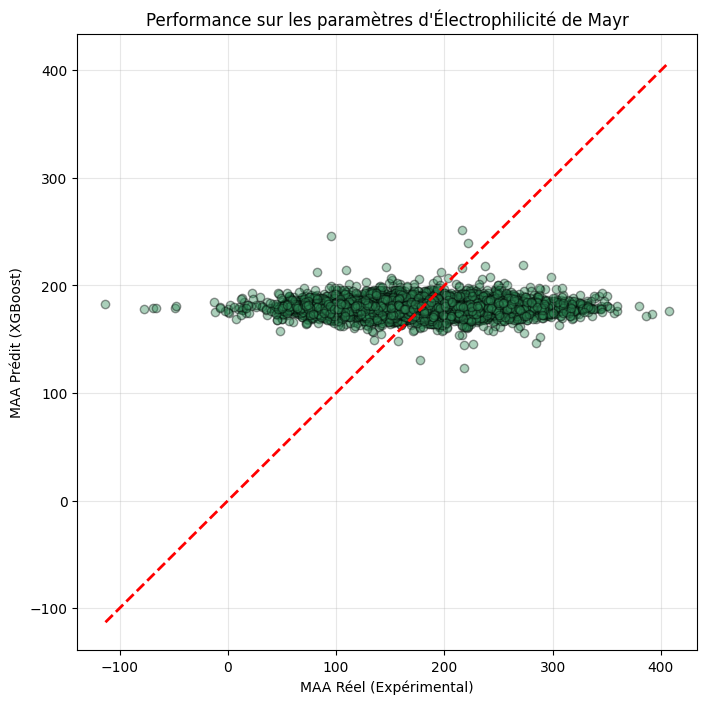

In [62]:
import matplotlib.pyplot as plt

# 1. On s'assure d'utiliser les vraies valeurs non-scalées pour l'affichage
# (Si tu as fait un y_test = scaler.transform, utilise y_test_ori)

plt.figure(figsize=(8, 8))

# On utilise tes vraies colonnes
plt.scatter(y_test, preds_xgb, alpha=0.4, c='seagreen', edgecolors='k')

# Ligne de perfection
max_val = max(y_test.max(), preds_xgb.max())
min_val = min(y_test.min(), preds_xgb.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel("MAA Réel (Expérimental)")
plt.ylabel("MAA Prédit (XGBoost)")
plt.title("Performance sur les paramètres d'Électrophilicité de Mayr")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import pandas as pd

# On crée un DataFrame avec tes données d'entraînement
df_corr = pd.DataFrame(X_train_ori)
df_corr['target'] = y_train

# On calcule la corrélation de chaque colonne avec la cible (MAA_values)
correlations = df_corr.corr()['target'].abs().sort_values(ascending=False)

print("🔍 ANALYSE DE CORRÉLATION (Top 10) :")
print(correlations.head(11)) # 11 pour ignorer la corrélation de 'target' avec elle-même

🔍 ANALYSE DE CORRÉLATION (Top 10) :
target    1.000000
158       0.015730
42        0.011726
0         0.011726
173       0.011595
178       0.010280
144       0.009506
9         0.009306
200       0.009098
140       0.008735
146       0.008398
Name: target, dtype: float64
